In [1]:
#Load other modules specific to this notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random as rnd
from scipy import signal
from sklearn.preprocessing import scale
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

#Create a print formatting class
class printFormat:
    bold = '\033[1m'
    italic = '\033[3m'
    end = '\033[0m'

!eeggan setup_tutorial

eeggan_training_example.csv has been downloaded and saved to directory data.
eeggan_validation_example.csv has been downloaded and saved to directory data.
pretrained_autoencoder.pt has been downloaded and saved to directory trained_ae.
pretrained_gan.pt has been downloaded and saved to directory trained_models.
EEG-GAN tutorial files have been downloaded.


In [2]:
#Load the data
empiricalHeaders = np.genfromtxt('dataset_eeg_train_3_subj_3_sess.csv', delimiter=',', names=True).dtype.names
empiricalEEG = np.genfromtxt('dataset_eeg_train_3_subj_3_sess.csv', delimiter=',', skip_header=1)

#Print the head of the data
print(printFormat.bold + 'Display Header and first few rows/columns of data\n \033[0m' + printFormat.end)
print(pd.DataFrame(empiricalEEG, columns=empiricalHeaders).iloc[:5,:6])

#Print some information about the columns
print('\n' + '-'*90)
print(f"{printFormat.bold}\nNote the first four columns:{printFormat.end}\n"
      f"    ParticipantID - Indicates different participants\n"
      f"    Condition - Indicates the condition (WIN = 0, LOSE = 1) to be classified\n"
      f"    Trial - Indicates the trial number for that participant and condition\n"
      f"    Electrode - a numerical number ID of each electrode")
print('\nThe remaining columns are titled Time1 to Time100 - indicating 100 datapoints per sample.\n'
      'The samples span from -200 to 1000ms around the onset of a feedback stimulus.\n'
      'These are downsampled from the original data, which contained 600 datapoints per sample.')

# Print some meta-data
print('\n' + '-'*90)
print(f"\n{printFormat.bold}Other characteristics of our data include:{printFormat.end}")
print(f"-We have {len(set(empiricalEEG[:,0]))} participants in our training set")
average_trials = round(np.mean([np.max(empiricalEEG[empiricalEEG[:,0] == pID, 2]) for pID in set(empiricalEEG[:,0])]))
std_trials = round(np.std([np.max(empiricalEEG[empiricalEEG[:,0] == pID, 2]) for pID in set(empiricalEEG[:,0])]))
print(f"-Participants have an average of {average_trials} (SD: {std_trials}) trials per outcome (win, lose)")
print(f"-There are a total of {len(empiricalEEG)} samples in our data")
print(f"-There is {len(set(empiricalEEG[:,3]))} electrode in our data")


Display Header and first few rows/columns of data
 
   ParticipantID  Condition  Trial  Electrode     Time1     Time2
0            3.0        0.0    1.0        1.0 -1.820944 -7.117353
1            3.0        0.0    1.0        2.0 -7.244745 -8.428855
2            3.0        0.0    1.0        3.0 -7.260283 -6.727294
3            3.0        0.0    1.0        4.0 -6.918266 -9.099522
4            3.0        0.0    1.0        5.0  3.372935  0.652466

------------------------------------------------------------------------------------------

Note the first four columns:
    ParticipantID - Indicates different participants
    Condition - Indicates the condition (WIN = 0, LOSE = 1) to be classified
    Trial - Indicates the trial number for that participant and condition
    Electrode - a numerical number ID of each electrode

The remaining columns are titled Time1 to Time100 - indicating 100 datapoints per sample.
The samples span from -200 to 1000ms around the onset of a feedback stimulus.
T

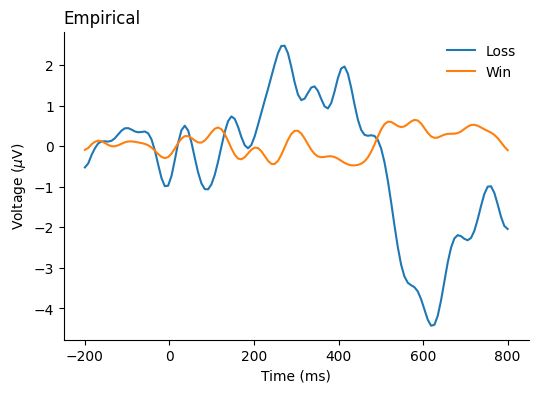

In [3]:
#Determine which rows are each condition
lossIndex = np.where(empiricalEEG[:,1]==1)
winIndex = np.where(empiricalEEG[:,1]==0)

#Grand average the waveforms for each condition
lossWaveform = np.mean(empiricalEEG[lossIndex,4:],axis=1)[0]
winWaveform = np.mean(empiricalEEG[winIndex,4:],axis=1)[0]

#Determine x axis of time
time = np.linspace(-200,800,128)

#Setup figure
f, (ax1) = plt.subplots(1, 1, figsize=(6, 4))

#Plot each waveform
ax1.plot(time, lossWaveform, label = 'Loss')
ax1.plot(time, winWaveform, label = 'Win')

#Format plot
ax1.set_ylabel('Voltage ($\mu$V)')
ax1.set_xlabel('Time (ms)')
ax1.set_title('Empirical', loc='left')
ax1.spines[['right', 'top']].set_visible(False)
ax1.legend(frameon=False)

In [5]:
# Train Autoencoder Parameters
data = 'dataset_eeg_train_3_subj_3_sess.csv'
save_name = 'my_autoencoder_subj_3_sess_3.pt'
kw_channel = 'Electrode'
#kw_conditions = ['Condition','ParticipantID']
target = 'time'
time_out = 64
n_epochs = 2000
seed = 42

# Train the Autoencoder
!eeggan autoencoder_training \
    data={data} \
    save_name={save_name} \
    kw_channel={kw_channel} \
    kw_conditions=Condition \
    target={target} \
    time_out={time_out} \
    n_epochs=2000 \
    batch_size=64 \
    learning_rate=0.0001 \
    seed={seed}

#---------------------------------------------------------------------#
#---------------------------------------------------------------------#

# Alternatively, you could have written all parameters in place:
#!eeggan autoencoder_training data='data/eeggan_training_example.csv' save_name='test_ae.pt' kw_channel='Electrode' target='time' time_out=50 n_epochs=10 seed=42

Traceback (most recent call last):
  File "/home/giorgio99/miniconda3/envs/eeg_research/bin/eeggan", line 3, in <module>
    from eeggan.__main__ import main
  File "/home/giorgio99/miniconda3/envs/eeg_research/lib/python3.11/site-packages/eeggan/__main__.py", line 7, in <module>
    from .visualize_main import main as visualize_main
  File "/home/giorgio99/miniconda3/envs/eeg_research/lib/python3.11/site-packages/eeggan/visualize_main.py", line 14, in <module>
    from eeggan.helpers.visualize_spectogram import plot_fft_hist, plot_spectogram
  File "/home/giorgio99/miniconda3/envs/eeg_research/lib/python3.11/site-packages/eeggan/helpers/visualize_spectogram.py", line 2, in <module>
    from scipy import signal
  File "<frozen importlib._bootstrap>", line 1229, in _handle_fromlist
  File "/home/giorgio99/miniconda3/envs/eeg_research/lib/python3.11/site-packages/scipy/__init__.py", line 131, in __getattr__
    return _importlib.import_module(f'scipy.{name}')
           ^^^^^^^^^^^^^^^^^

In [4]:
!eeggan lae_training \
    data='EEG-synthetic/dataset_eeg_train_3_subj_3_sess.csv' \
    autoencoder='trained_ae/my_autoencoder_subj_3_sess_3.pt' \
            kw_conditions=Condition \
    kw_channel='Electrode' \
    n_epochs=1000 \
    batch_size=64 \
    save_name='test_latent_ae_v1' \
    patch_size=16 \
            ae_lr=0.0001 \
    seed=42

>>> MAIN AVVIATO <<<

-----------------------------------------
Command line arguments:
-----------------------------------------

Dataset: EEG-synthetic/dataset_eeg_train_3_subj_3_sess.csv
Using temporal AE: trained_ae/my_autoencoder_subj_3_sess_3.pt
Conditions: ['Condition']
Channel label: Electrode
Number of epochs: 1000
Batch size: 64
Model save name: test_latent_ae_v1
Patch size: 16
AE learning rate: 0.0001
Manual seed: 42
>>> CERCO IL FILE IN: /home/giorgio99/gan_bci/EEG-synthetic/dataset_eeg_train_3_subj_3_sess.csv

--- DEBUG DIMENSIONI DATASET ---
Shape totale del dataset caricato: torch.Size([1600, 129, 8])
Shape delle etichette (labels): 1
Wrapper Discriminatore FORZATO a True
Wrapper Generatore FORZATO a True
Generator and discriminator initialized.

-----------------------------------------
Training Latent AE...
-----------------------------------------

Calculating weights for class balancing...
100%|█████████████| 1000/1000 [10:13<00:00,  1.63it/s, RECON LOSS (L2): 0.0010

In [6]:
# Se i tuoi dati sono nel file che abbiamo creato prima:

!eeggan gan_training \
    data='dataset_eeg_train_3_subj_3_sess.csv' \
    autoencoder='trained_ae/my_autoencoder_subj_3_sess_3.pt' \
    checkpoint='trained_models/test_latent_ae_v1.pt' \
    save_name='my_aegan_w_lae_subj_3_sess_3.pt' \
    kw_conditions=Condition \
    kw_channel='Electrode' \
    patch_size=16 \
    n_epochs=2000 \
    batch_size=64 \
    generator_lr=0.0001 \
    discriminator_lr=0.0001 \
    seed=42
# Train the AE-GAN on GPUs
#!eeggan gan_training ddp data={data} autoencoder={autoencoder} save_name={save_name} kw_conditions={kw_conditions} kw_channel={kw_channel} patch_size={patch_size} n_epochs={n_epochs} seed={seed}
# Note, on Google Colab you can start a GPU runtime by going to Runtime > Change runtime type > Hardware accelerator > GPU

#---------------------------------------------------------------------#
#---------------------------------------------------------------------#

# Alternatively, you could have written all parameters in place:
#!eeggan gan_training data='data/eeggan_training_example.csv' autoencoder='trained_ae/test_ae.pt' save_name='demo_aegan.pt' kw_conditions='Condition' kw_channel='Electrode' patch_size=10 n_epochs=10 seed=42
#!eeggan gan_training data='data/eeggan_training_example.csv' ddp autoencoder='trained_ae/test_ae.pt' save_name='demo_aegan.pt' kw_conditions='Condition' kw_channel='Electrode' patch_size=10 n_epochs=10 seed=42



-----------------------------------------
Command line arguments:
-----------------------------------------

Dataset: dataset_eeg_train_3_subj_3_sess.csv
Using autoencoder: trained_ae/my_autoencoder_subj_3_sess_3.pt
Using pre-trained GAN: trained_models/test_latent_ae_v1.pt
Model save name: my_aegan_w_lae_subj_3_sess_3.pt
Conditions: ['Condition']
Channel label: Electrode
Patch size: 16
Number of epochs: 2000
Batch size: 64
Generator learning rate: 0.0001
Discriminator learning rate: 0.0001
Manual seed: True
Resuming training from checkpoint trained_models/test_latent_ae_v1.pt.
Resuming training from checkpoint trained_models/test_latent_ae_v1.pt.
>>> Pesi pre-train Latent AE caricati con successo!
>>> Info: Chiave 'discriminator_lr' non presente nel checkpoint, inizializzata ex-novo.
>>> Info: Chiave 'generator_lr' non presente nel checkpoint, inizializzata ex-novo.
>>> Info: Chiave 'critic_iterations' non presente nel checkpoint, inizializzata ex-novo.
>>> Info: Chiave 'lambda_gp' n


--- Metriche Wasserstein (Classe 1) ---
Canale 0: 0.0734
Canale 1: 0.0694
Canale 2: 0.1020
Canale 3: 0.1110
Canale 4: 0.1110
Canale 5: 0.0870
Canale 6: 0.1051
Canale 7: 0.1183
DISTANZA MEDIA DI WASSERSTEIN: 0.0971


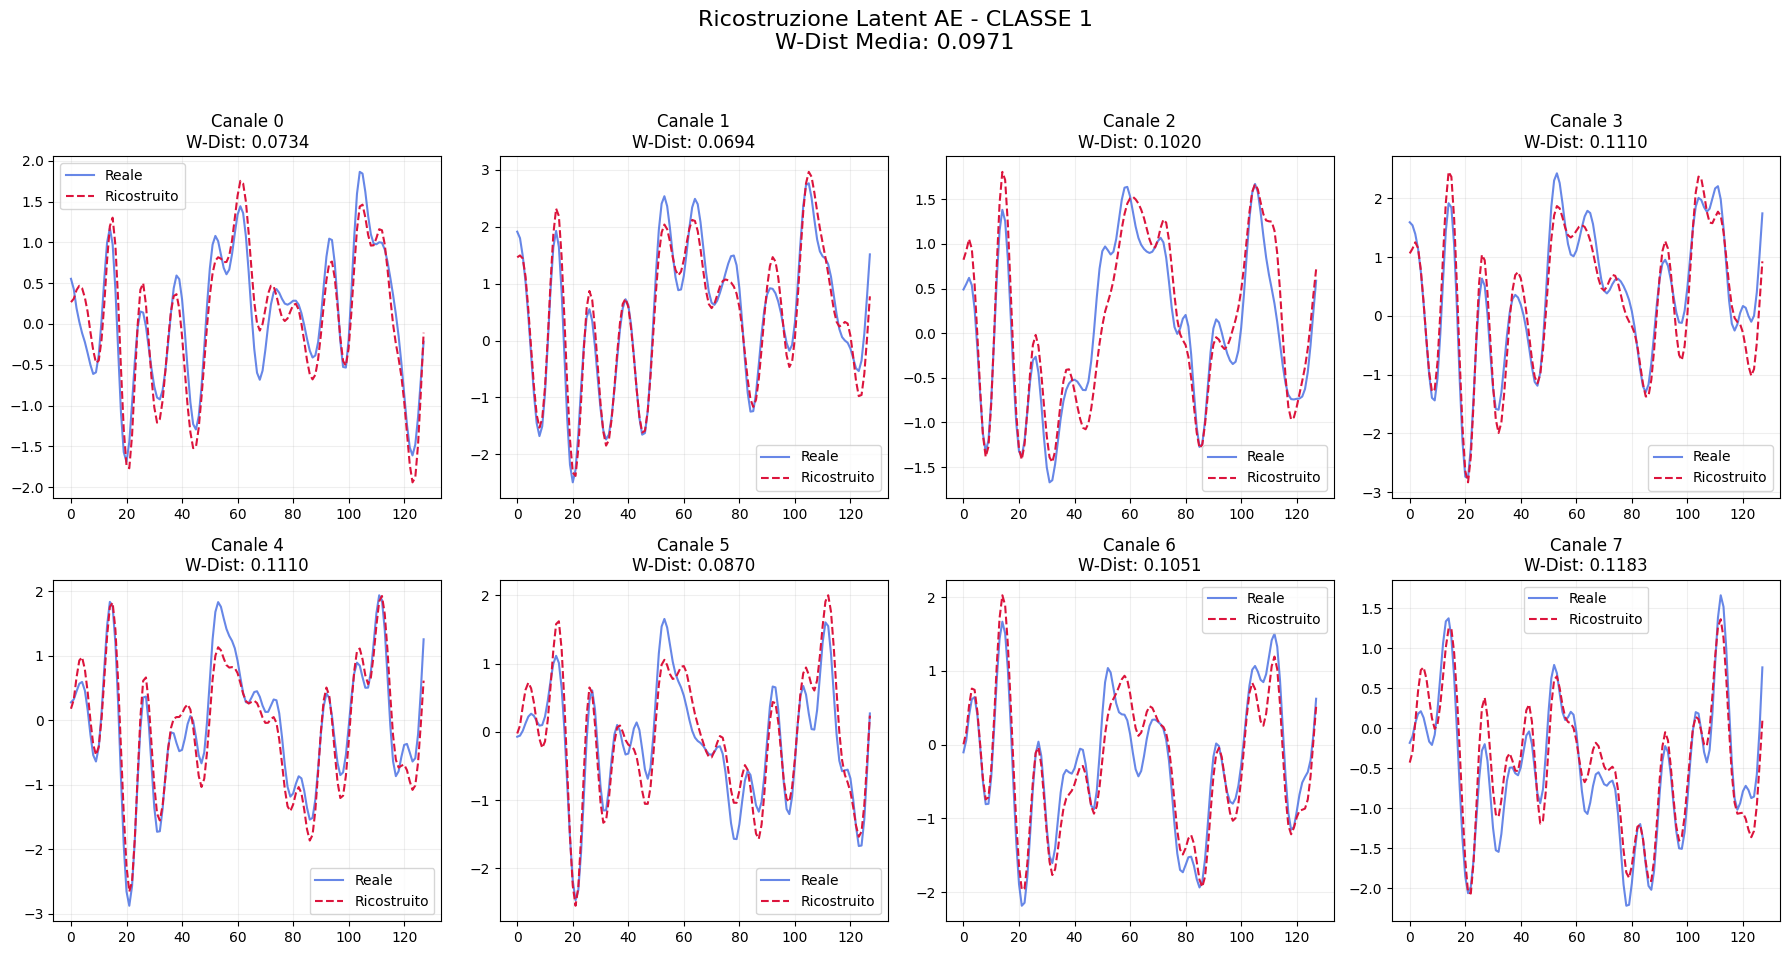

In [5]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wasserstein_distance # Libreria fondamentale per la metrica
from eeggan.helpers.dataloader import Dataloader
from eeggan.helpers.initialize_gan import init_gan

def standardize_signal(tensor):
    """Standardizza il segnale: (x - mean) / std lungo l'asse del tempo."""
    # Nota: manteniamo la tua logica di standardizzazione globale sul trial
    mean = tensor.mean()
    std = tensor.std()
    return (tensor - mean) / (std)

def visualize_class_reconstruction(checkpoint_path, data_path, target_class=1):
    # 1. Caricamento Checkpoint
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    opt = checkpoint['configuration']
    
    latent_dim = opt.get('latent_dim', 128)
    n_cond = opt.get('n_conditions', 1)
    n_channels = opt.get('n_channels', 8)
    opt['latent_dim_in'] = latent_dim + n_cond
    opt['channel_in_disc'] = n_channels + n_cond
    opt['device'] = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 2. Inizializzazione Modelli
    generator, discriminator = init_gan(**opt)
    
    key_gen = 'generator' if 'generator' in checkpoint else 'generator_state_dict'
    key_disc = 'discriminator' if 'discriminator' in checkpoint else 'discriminator_state_dict'
    generator.load_state_dict(checkpoint[key_gen])
    discriminator.load_state_dict(checkpoint[key_disc])
    
    generator.to(opt['device']).eval()
    discriminator.to(opt['device']).eval()
    discriminator.encode_input(True)
    generator.decode_output(True)

    # 3. Caricamento Dati
    dataloader = Dataloader(data_path, kw_time=opt['kw_time'], 
                            kw_conditions=opt['kw_conditions'], kw_channel=opt['kw_channel'])
    dataset = dataloader.get_data()
    labels_all = dataset[:, 0, 0].numpy()
    indices = np.where(np.round(labels_all) == target_class)[0]
    
    if len(indices) == 0: return
    
    sample_idx = indices[0]
    trial = dataset[sample_idx:sample_idx+1].to(opt['device']).float()
    real_labels = trial[:, :n_cond, 0].unsqueeze(1) 
    real_eeg_raw = trial[:, n_cond:, :]
    real_eeg = standardize_signal(real_eeg_raw)

    # 4. Pipeline di Ricostruzione
    with torch.no_grad():
        real_reduced = discriminator.encoder.encode(real_eeg)
        repeated_labels = real_labels.repeat(1, 1, real_reduced.shape[1]).permute(0, 2, 1)
        encoder_input = torch.cat((real_reduced, repeated_labels), dim=-1)
        
        base_disc = discriminator.discriminator if hasattr(discriminator, 'discriminator') else discriminator
        encoder_head = torch.nn.Sequential(
            base_disc[0], base_disc[1], base_disc[2].clshead[0], base_disc[2].clshead[1]
        ).to(opt['device'])
        z = encoder_head(encoder_input)
        
        cond = real_labels.view(1, -1)
        z_conditioned = torch.cat((z, cond), dim=-1)
        recon_reduced = generator.generator(z_conditioned)
        recon_full_raw = generator.decoder.decode(recon_reduced)
        recon_full = standardize_signal(recon_full_raw)

    # 5. CALCOLO DISTANZA DI WASSERSTEIN
    wasserstein_scores = []
    print(f"\n--- Metriche Wasserstein (Classe {target_class}) ---")
    
    for i in range(n_channels):
        r_np = real_eeg[0, :, i].cpu().numpy()
        s_np = recon_full[0, :, i].cpu().numpy()
        
        # Calcolo della distanza di Wasserstein 1D
        dist = wasserstein_distance(r_np, s_np)
        wasserstein_scores.append(dist)
        print(f"Canale {i}: {dist:.4f}")

    mean_wasserstein = np.mean(wasserstein_scores)
    print(f"DISTANZA MEDIA DI WASSERSTEIN: {mean_wasserstein:.4f}")

    # 6. Visualizzazione
    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    axes = axes.flatten()
    
    for i in range(8):
        r_np = real_eeg[0, :, i].cpu().numpy()
        s_np = recon_full[0, :, i].cpu().numpy()
        
        axes[i].plot(r_np, label='Reale', color='royalblue', alpha=0.8)
        axes[i].plot(s_np, label='Ricostruito', color='crimson', linestyle='--')
        axes[i].set_title(f"Canale {i}\nW-Dist: {wasserstein_scores[i]:.4f}")
        axes[i].legend()
        axes[i].grid(True, alpha=0.2)

    plt.suptitle(f"Ricostruzione Latent AE - CLASSE {target_class}\nW-Dist Media: {mean_wasserstein:.4f}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Esecuzione
visualize_class_reconstruction(
    checkpoint_path='trained_models/test_latent_ae_v1.pt',
    data_path='dataset_eeg_test_3_subj_3_sess.csv',
    target_class=1
)

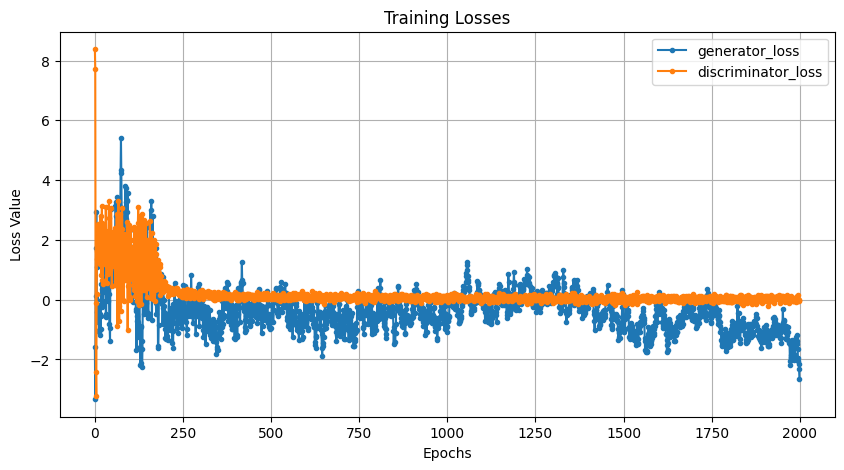

In [7]:
import torch
import matplotlib.pyplot as plt

# Carica il modello
state_dict = torch.load('trained_models/my_aegan_w_lae_subj_3_sess_3.pt', map_location='cpu')

plt.figure(figsize=(10, 5))

# Seguendo la logica di visualize_main.py: cerca tutte le chiavi che contengono "loss"
loss_found = False
for key in state_dict.keys():
    if 'loss' in key:
        plt.plot(state_dict[key], label=key, marker='.')
        loss_found = True

if loss_found:
    plt.title('Training Losses')
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Nessuna chiave 'loss' trovata nel file. Chiavi disponibili:", state_dict.keys())




In [8]:
!eeggan generate_samples_lae \
    model=trained_models/my_aegan_w_lae_subj_3_sess_3.pt \
            checkpoint=trained_models/test_latent_ae_v1.pt \
    conditions=0 \
    num_samples_total=1200\
    num_samples_parallel=20 \
    save_name=aegan_w_lae_data_c0_subj_3_sess_3.csv \
    seed=42
!eeggan generate_samples_lae \
        model=trained_models/my_aegan_w_lae_subj_3_sess_3.pt \
                checkpoint=trained_models/test_latent_ae_v1.pt \
        conditions=1 \
    num_samples_total=1200 \
    num_samples_parallel=20 \
    save_name=aegan_w_lae_data_c1_subj_3_sess_3.csv \
    seed=42



-----------------------------------------
Command line arguments:
-----------------------------------------

Model: trained_models/my_aegan_w_lae_subj_3_sess_3.pt
AE Checkpoint: trained_models/test_latent_ae_v1.pt
Condition: [0]
Total samples: 1200
Batch size: 20
Save name: aegan_w_lae_data_c0_subj_3_sess_3.csv
Manual seed: 42

-----------------------------------------
System output:
-----------------------------------------

Initializing generator...
Loading PURE Encoder weights from: trained_models/test_latent_ae_v1.pt
>>> GARANZIA: Encoder AE (puro) e Generator GAN (rifinito) pronti.
Generating samples...
Generating sequence 1/60...
Generating sequence 2/60...
Generating sequence 3/60...
Generating sequence 4/60...
Generating sequence 5/60...
Generating sequence 6/60...
Generating sequence 7/60...
Generating sequence 8/60...
Generating sequence 9/60...
Generating sequence 10/60...
Generating sequence 11/60...
Generating sequence 12/60...
Generating sequence 13/60...
Generating sequ

In [9]:

syntheticHeaders = np.genfromtxt('generated_samples/aegan_w_lae_data_c0_subj_3_sess_3.csv', delimiter=',', names=True).dtype.names
gan_c0 = np.genfromtxt('generated_samples/aegan_w_lae_data_c0_subj_3_sess_3.csv', delimiter=',', skip_header=1)
gan_c1 = np.genfromtxt('generated_samples/aegan_w_lae_data_c1_subj_3_sess_3.csv', delimiter=',', skip_header=1)
syntheticEEG = np.concatenate((gan_c0,gan_c1),axis=0)

#Print head of the data
print(f"{printFormat.bold}Display first few rows/columns of data{printFormat.end}")
print(pd.DataFrame(syntheticEEG, columns=syntheticHeaders).iloc[:5,:6])

# Print condition sample counts
print(f"\n{printFormat.bold}Display trial counts for each condition{printFormat.end}")
print(f"{printFormat.bold}Win: {printFormat.end}{np.sum(syntheticEEG[:, 0] == 0)}")
print(f"{printFormat.bold}Lose: {printFormat.end}{np.sum(syntheticEEG[:, 0] == 1)}")

Display first few rows/columns of data
   Condition  Electrode     Time0     Time1     Time2     Time3
0        0.0        1.0  0.253435  0.146577 -0.475435 -1.416400
1        0.0        2.0  0.279296  0.188011 -0.261639 -1.005373
2        0.0        3.0  0.207695  0.108520 -0.189203 -0.719609
3        0.0        4.0  0.764810  0.510645 -0.406287 -1.584771
4        0.0        5.0  1.009718  0.664508 -0.214352 -1.190939

Display trial counts for each condition
Win: 9600
Lose: 9600


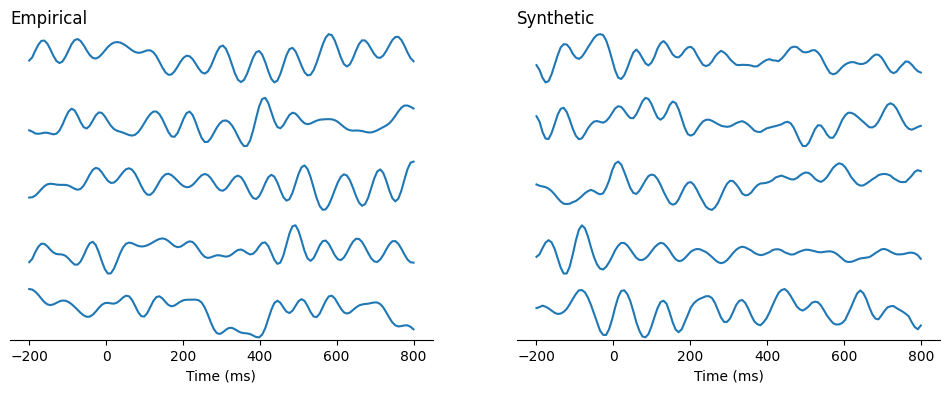

In [10]:
#Determine 5 random trials to plot
empiricalIndex = rnd.sample(range(0, empiricalEEG.shape[0]), 5)
syntheticIndex = rnd.sample(range(0, syntheticEEG.shape[0]), 5)

#Plot trial data
f, ax = plt.subplots(5, 2, figsize=(12, 4))
for c in range(5):
    ax[c,0].plot(time,empiricalEEG[empiricalIndex[c],4:]) #Note, we here add the same filter simply for visualization
    ax[c,0].set_yticks([])

    ax[c,1].plot(time,syntheticEEG[syntheticIndex[c],2:])
    ax[c,1].spines[['left', 'right', 'top']].set_visible(False)
    ax[c,1].set_yticks([])

    if c == 0:
        ax[c,0].set_title('Empirical', loc='left')
        ax[c,1].set_title('Synthetic', loc='left')
    else:
        ax[c,0].set_title(' ')
        ax[c,1].set_title(' ')

    if c != 4:
        ax[c,0].spines[['bottom', 'left', 'right', 'top']].set_visible(False)
        ax[c,1].spines[['bottom', 'left', 'right', 'top']].set_visible(False)
        ax[c,0].set_xticks([])
        ax[c,1].set_xticks([])
    else:
        ax[c,0].spines[['left', 'right', 'top']].set_visible(False)
        ax[c,1].spines[['left', 'right', 'top']].set_visible(False)
        ax[c,0].set_xlabel('Time (ms)')
        ax[c,1].set_xlabel('Time (ms)')

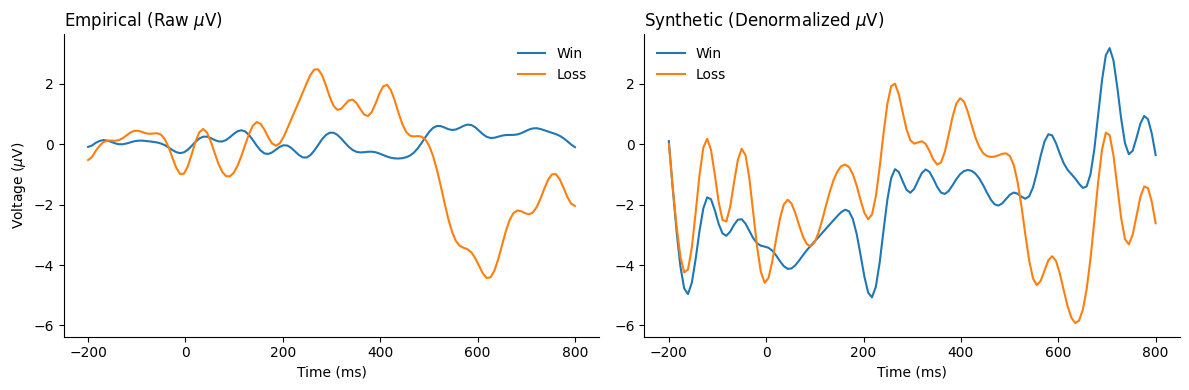

In [11]:
def filter_synthetic(EEG, fs=128):
    """
    Applica un filtro passa-banda 0.1-30Hz.
    EEG deve avere forma (trial, punti_temporali)
    """
    # Progettazione del filtro Butterworth (4° ordine)
    # 0.1 Hz rimuove il drift (il segnale che scivola via dallo zero)
    # 30 Hz rimuove il rumore ad alta frequenza (le "seghettature" della GAN)
    lowcut = 0.1
    highcut = 15.0
    
    # Progettiamo il filtro usando fs=128 esplicito
    b, a = signal.butter(4, [lowcut, highcut], btype='bandpass', fs=fs)

    # Applichiamo il filtro lungo l'asse del tempo (axis=-1)
    # filtfilt è fondamentale: applica il filtro due volte (avanti e indietro)
    # per avere sfasamento zero (i picchi P300 restano al millisecondo giusto)
    filteredEEG = signal.filtfilt(b, a, EEG, axis=-1)

    return filteredEEG


# Nota: Assicurati che winWaveform e lossWaveform (Empirical) 
# siano già i valori medi dei dati grezzi. 
# Se sono stati caricati tramite dataloader Z-score, denormalizza anche loro.
# --- APPLICAZIONE AI TUOI DATI ---
# Supponendo che syntheticEEG contenga [Label, TrialID, Time1...Time128]
# Filtriamo solo le colonne del segnale (dalla 2 in poi)
syntheticEEG[:, 2:] = filter_synthetic(syntheticEEG[:, 2:], fs=128)

#Grand average the synthetic waveforms for each condition
synLossWaveform = np.mean(syntheticEEG[np.r_[syntheticEEG[:,0]==1],2:],axis=0)
synWinWaveform = np.mean(syntheticEEG[np.r_[syntheticEEG[:,0]==0],2:],axis=0)

raw_eeg_data = empiricalEEG[:, 4:]
mu_real = np.mean(raw_eeg_data)
std_real = np.std(raw_eeg_data)
# Applica l'inversa dello Z-score: (x * std) + mean
synWinWaveform_uV = (synWinWaveform * std_real) + mu_real
synLossWaveform_uV = (synLossWaveform * std_real) + mu_real
# Setup figure
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True) # sharey=True serve per confrontarli bene

# --- PLOT EMPIRICAL ---
# Rimuoviamo scale() per vedere i microvolt reali
ax1.plot(time, winWaveform, label = 'Win', color='tab:blue')
ax1.plot(time, lossWaveform, label = 'Loss', color='tab:orange')

ax1.set_ylabel('Voltage ($\mu$V)')
ax1.set_xlabel('Time (ms)')
ax1.set_title('Empirical (Raw $\mu$V)', loc='left')
ax1.spines[['right', 'top']].set_visible(False)
ax1.tick_params(left = True, labelleft = True) # RIATTIVA i numeri a sinistra
ax1.legend(frameon=False)

# --- PLOT SYNTHETIC ---
# Usiamo i dati denormalizzati e rimuoviamo scale()
ax2.plot(time, synWinWaveform_uV, label = 'Win', color='tab:blue')
ax2.plot(time, synLossWaveform_uV, label = 'Loss', color='tab:orange')

ax2.set_xlabel('Time (ms)')
ax2.set_title('Synthetic (Denormalized $\mu$V)', loc='left')
ax2.spines[['right', 'top']].set_visible(False)
ax2.tick_params(left = True, labelleft = True) # RIATTIVA i numeri
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()

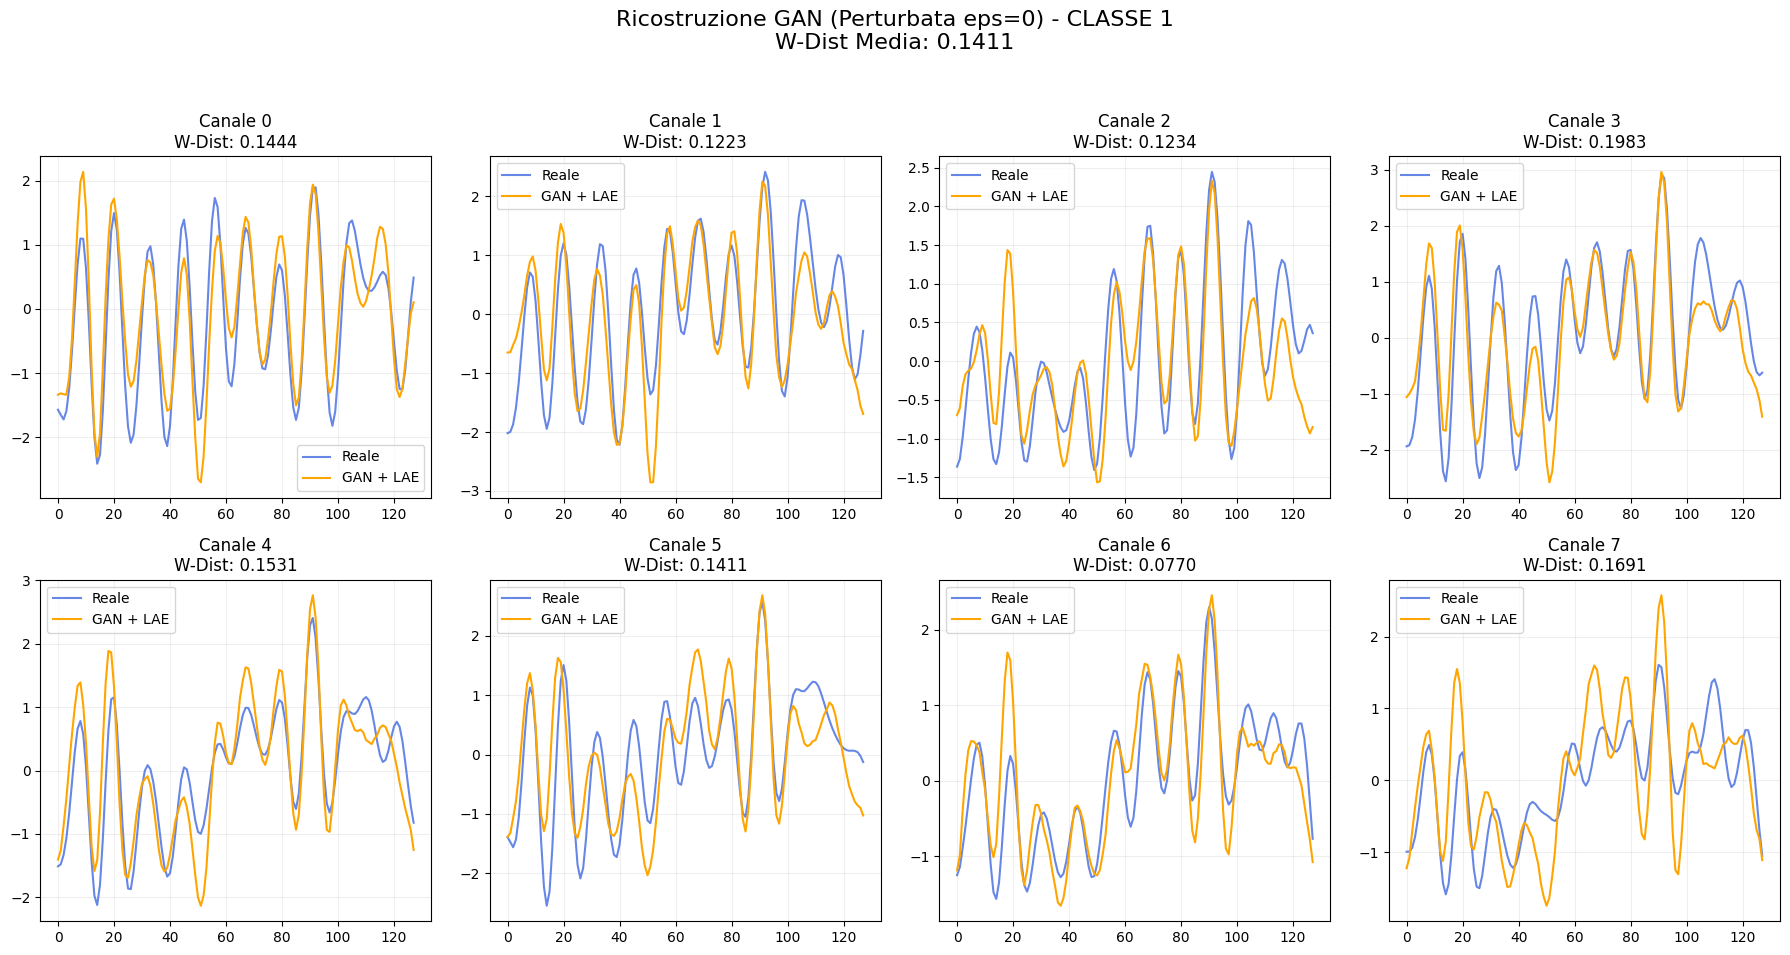

In [12]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.stats import wasserstein_distance
from eeggan.helpers.dataloader import Dataloader
from eeggan.helpers.initialize_gan import init_gan

def standardize_signal(tensor):
    """Standardizza il segnale: (x - mean) / std."""
    mean = tensor.mean()
    std = tensor.std()
    return (tensor - mean) / (std)

def visualize_gan_reconstruction(gan_checkpoint_path, lae_checkpoint_path, data_path, target_class=1, epsilon=0.05):
    """
    Usa l'encoder del LAE e il generatore della GAN per ricostruire un segnale reale.
    """
    # 1. Caricamento Checkpoint GAN e LAE
    gan_checkpoint = torch.load(gan_checkpoint_path, map_location='cpu')
    lae_checkpoint = torch.load(lae_checkpoint_path, map_location='cpu')
    
    opt = gan_checkpoint['configuration']
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    opt['device'] = device

    # Fix parametri dimensionali per init_gan
    n_cond = opt.get('n_conditions', 1)
    n_channels = opt.get('n_channels', 8)
    latent_dim = opt.get('latent_dim', 128)
    opt['latent_dim_in'] = latent_dim + n_cond
    opt['channel_in_disc'] = n_channels + n_cond

    # 2. Inizializzazione Modelli
    generator, discriminator = init_gan(**opt)
    
    # --- LOGICA DOUBLE LOADING ---
    # Carichiamo il GENERATORE dalla GAN (Raffinato)
    key_gen = 'generator' if 'generator' in gan_checkpoint else 'generator_state_dict'
    generator.load_state_dict(gan_checkpoint[key_gen])
    
    # Carichiamo il DISCRIMINATORE/ENCODER dal LAE (Puro)
    key_disc = 'discriminator' if 'discriminator' in lae_checkpoint else 'discriminator_state_dict'
    discriminator.load_state_dict(lae_checkpoint[key_disc])
    
    generator.to(device).eval()
    discriminator.to(device).eval()
    discriminator.encode_input(True)
    generator.decode_output(True)

    # 3. Caricamento Dati Reali
    dataloader = Dataloader(data_path, kw_time=opt['kw_time'], 
                            kw_conditions=opt['kw_conditions'], kw_channel=opt['kw_channel'])
    dataset = dataloader.get_data()
    labels_all = dataset[:, 0, 0].numpy()
    indices = np.where(np.round(labels_all) == target_class)[0]
    
    if len(indices) == 0:
        print(f"Nessun trial trovato per classe {target_class}")
        return
    
    sample_idx = indices[0] # Prendiamo il primo trial reale di quella classe
    trial = dataset[sample_idx:sample_idx+1].to(device).float()
    
    real_labels = trial[:, :n_cond, 0].unsqueeze(1) 
    real_eeg_raw = trial[:, n_cond:, :]
    real_eeg = standardize_signal(real_eeg_raw)

    # 4. Pipeline di Generazione GAN (Encoding AE -> Perturbazione -> Decoding GAN)
    with torch.no_grad():
        # A. Riduzione temporale
        real_reduced = discriminator.encoder.encode(real_eeg)
        
        # B. Preparazione 9 canali per l'Encoder
        repeated_labels = real_labels.repeat(1, 1, real_reduced.shape[1]).permute(0, 2, 1)
        encoder_input = torch.cat((real_reduced, repeated_labels), dim=-1)
        
        # C. Estrazione Latente con pesi AE
        base_disc = discriminator.discriminator if hasattr(discriminator, 'discriminator') else discriminator
        encoder_head = torch.nn.Sequential(
            base_disc[0], base_disc[1], base_disc[2].clshead[0], base_disc[2].clshead[1]
        ).to(device)
        z_real = encoder_head(encoder_input)
        
        # D. Applicazione Perturbazione (Eq. 7 della tua ricerca)
        noise = torch.randn_like(z_real)
        z_perturbed = z_real + (epsilon * noise)
        
        # E. Generazione con pesi GAN
        cond = real_labels.view(1, -1)
        z_final = torch.cat((z_perturbed, cond), dim=-1)
        recon_reduced = generator.generator(z_final)
        
        # F. Espansione temporale completa
        recon_full_raw = generator.decoder.decode(recon_reduced)
        recon_full = standardize_signal(recon_full_raw)

    # 5. Calcolo Metriche
    wasserstein_scores = []
    for i in range(n_channels):
        r_np = real_eeg[0, :, i].cpu().numpy()
        s_np = recon_full[0, :, i].cpu().numpy()
        wasserstein_scores.append(wasserstein_distance(r_np, s_np))

    # 6. Visualizzazione
    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    axes = axes.flatten()
    for i in range(min(8, n_channels)):
        r_np = real_eeg[0, :, i].cpu().numpy()
        s_np = recon_full[0, :, i].cpu().numpy()
        axes[i].plot(r_np, label='Reale', color='royalblue', alpha=0.8)
        axes[i].plot(s_np, label='GAN + LAE', color='orange', linewidth=1.5)
        axes[i].set_title(f"Canale {i}\nW-Dist: {wasserstein_scores[i]:.4f}")
        axes[i].legend()
        axes[i].grid(True, alpha=0.2)

    plt.suptitle(f"Ricostruzione GAN (Perturbata eps={epsilon}) - CLASSE {target_class}\nW-Dist Media: {np.mean(wasserstein_scores):.4f}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Esecuzione
visualize_gan_reconstruction(
    gan_checkpoint_path='trained_models/my_aegan_w_lae_subj_3_sess_3.pt',
    lae_checkpoint_path='trained_models/test_latent_ae_v1.pt',
    data_path='dataset_eeg_test_3_subj_3_sess.csv',
    target_class=1,
    epsilon=0 # Prova 0.0 per vedere la ricostruzione pura o 0.05 per la perturbazione
)

Parametri Denormalizzazione Z-score -> Media: 0.03 µV, Std: 13.84 µV
-------------------------------------------------------------------------------------
CLASSE     | DIVERSITÀ (Dist)     | VARIANZA (Std Media) | % CATTURATA
-------------------------------------------------------------------------------------
Win        | R:  240.27 S:  260.75 | R:   16.72 S:   15.62 |     108.52%
Loss       | R:  258.61 S:  231.11 | R:   16.43 S:   15.20 |      89.37%


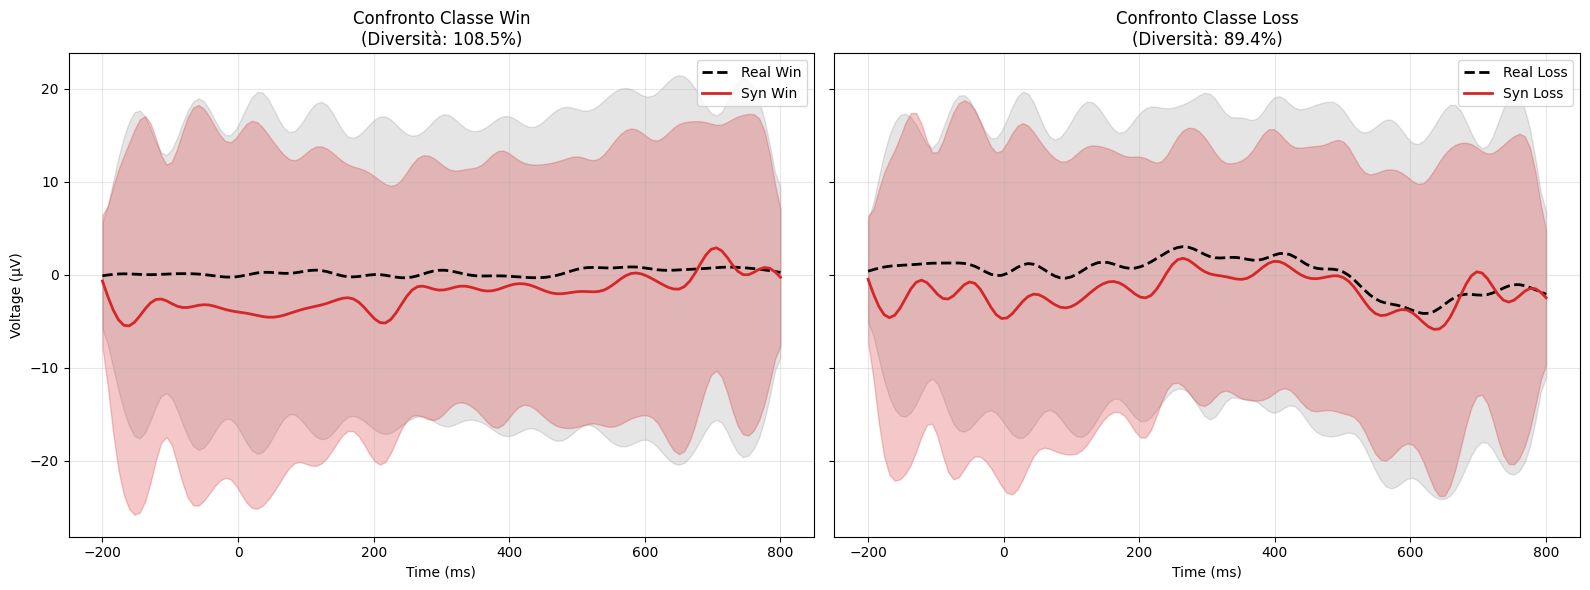

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.spatial.distance import pdist

# --- 1. FUNZIONI DI UTILITÀ ---

def filter_data(data, fs=128):
    """Filtro passa-banda Butterworth 0.1-15Hz (Ottimale per P300)"""
    b, a = signal.butter(4, [0.1, 15], btype='bandpass', fs=fs)
    return signal.filtfilt(b, a, data, axis=-1)

def compute_diversity(data):
    """Calcola la distanza Euclidea media tra trial (Metrica anti-Mode Collapse)"""
    n_samples = min(100, len(data))
    idx = np.random.choice(len(data), n_samples, replace=False)
    distances = pdist(data[idx, :], metric='euclidean')
    return np.mean(distances)

# --- 2. PREPARAZIONE DATI REALI ---

# Estrazione dati e labels (Assumendo colonna 1=Label, 4: = EEG grezzo in µV)
real_labels = empiricalEEG[:, 1]
real_data_raw = empiricalEEG[:, 4:]

# --- LOGICA Z-SCORE: Calcolo parametri dal training set originale ---
mu_train = np.mean(real_data_raw)
std_train = np.std(real_data_raw)

# Divisione per classe e filtraggio (sui dati in µV)
real_win = filter_data(real_data_raw[real_labels == 0])
real_loss = filter_data(real_data_raw[real_labels == 1])

# --- 3. PREPARAZIONE DATI SINTETICI ---

# Estrazione (Assumendo colonna 0=Label, 2: = EEG in formato Z-score)
syn_labels = syntheticEEG[:, 0]
syn_data_zscore = syntheticEEG[:, 2:]

# --- DENORMALIZZAZIONE Z-SCORE ---
# Riportiamo i dati da Z-score a Microvolt: (x * std) + mean
syn_data_denorm = (syn_data_zscore * std_train) + mu_train

# Filtraggio dati denormalizzati
syn_win = filter_data(syn_data_denorm[syn_labels == 0])
syn_loss = filter_data(syn_data_denorm[syn_labels == 1])

# --- 4. CALCOLO STATISTICHE E DIVERSITÀ ---

stats = {
    "Win":  {"real": real_win,  "syn": syn_win},
    "Loss": {"real": real_loss, "syn": syn_loss}
}

results = {}
for cls in ["Win", "Loss"]:
    results[cls] = {
        "div_real": compute_diversity(stats[cls]["real"]),
        "div_syn":  compute_diversity(stats[cls]["syn"]),
        "std_real": np.mean(np.std(stats[cls]["real"], axis=0)),
        "std_syn":  np.mean(np.std(stats[cls]["syn"], axis=0))
    }

# --- 5. STAMPA RISULTATI ---

print(f"Parametri Denormalizzazione Z-score -> Media: {mu_train:.2f} µV, Std: {std_train:.2f} µV")
print("-" * 85)
print(f"{'CLASSE':<10} | {'DIVERSITÀ (Dist)':<20} | {'VARIANZA (Std Media)':<20} | {'% CATTURATA'}")
print("-" * 85)
for cls in ["Win", "Loss"]:
    d_real = results[cls]['div_real']
    d_syn  = results[cls]['div_syn']
    s_real = results[cls]['std_real']
    s_syn  = results[cls]['std_syn']
    ratio  = (d_syn / d_real) * 100
    
    print(f"{cls:<10} | R:{d_real:>8.2f} S:{d_syn:>8.2f} | R:{s_real:>8.2f} S:{s_syn:>8.2f} | {ratio:>10.2f}%")

# --- 6. VISUALIZZAZIONE ---

time = np.linspace(-200, 800, real_win.shape[1])
f, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for i, cls in enumerate(["Win", "Loss"]):
    # Dati Reali (Nero tratteggiato)
    mu_r, std_r = np.mean(stats[cls]["real"], 0), np.std(stats[cls]["real"], 0)
    ax[i].plot(time, mu_r, label=f'Real {cls}', color='black', linestyle='--', lw=2)
    ax[i].fill_between(time, mu_r-std_r, mu_r+std_r, color='black', alpha=0.1)
    
    # Dati Sintetici (Rosso continuo)
    mu_s, std_s = np.mean(stats[cls]["syn"], 0), np.std(stats[cls]["syn"], 0)
    ax[i].plot(time, mu_s, label=f'Syn {cls}', color='tab:red', lw=2)
    ax[i].fill_between(time, mu_s-std_s, mu_s+std_s, color='tab:red', alpha=0.25)
    
    ax[i].set_title(f"Confronto Classe {cls}\n(Diversità: {results[cls]['div_syn']/results[cls]['div_real']*100:.1f}%)", fontsize=12)
    ax[i].legend(loc='upper right')
    ax[i].set_xlabel("Time (ms)")
    ax[i].grid(True, alpha=0.3)
    if i == 0: ax[i].set_ylabel("Voltage (µV)")

plt.tight_layout()
plt.show()

In [13]:
#Set seed for a bit of reproducibility
rnd.seed(42)

#This function averages trial-level empirical data for each participant and condition
def averageEEG(EEG):
    participants = np.unique(EEG[:,0])
    averagedEEG = []
    for participant in participants:
        for condition in range(2):
            averagedEEG.append(np.mean(EEG[(EEG[:,0]==participant)&(EEG[:,1]==condition),:], axis=0))
    return np.array(averagedEEG)

#Load test data to predict (data that neither the GAN nor the classifier will ever see in training)
EEGDataTest = np.genfromtxt('dataset_eeg_test_3_subj_all_sess.csv', delimiter=',', skip_header=1)
EEGDataTest = averageEEG(EEGDataTest)[:,1:]

#Extract test outcome and predictor data
y_test = EEGDataTest[:,0]
x_test = EEGDataTest[:,3:]
x_test = scale(x_test,axis = 1)

In [14]:
#Create participant by condition averages
Emp_train = averageEEG(empiricalEEG)[:,1:]

#Extract the outcomes
Emp_Y_train = Emp_train[:,0]

#Scale the predictors
Emp_X_train = scale(Emp_train[:,3:], axis=1)

#Shuffle the order of samples
trainShuffle = rnd.sample(range(len(Emp_X_train)),len(Emp_X_train))
Emp_Y_train = Emp_Y_train[trainShuffle]
Emp_X_train = Emp_X_train[trainShuffle,:]

In [15]:
#This function averages trial-level synthetic data in bundles of 50 trials, constrained to each condition
def averageSynthetic(synData):
    samplesToAverage = 50

    lossSynData = synData[synData[:,0]==0,:]
    winSynData = synData[synData[:,0]==1,:]

    lossTimeIndices = np.arange(0,lossSynData.shape[0],samplesToAverage)
    winTimeIndices = np.arange(0,winSynData.shape[0],samplesToAverage)

    newLossSynData = [np.insert(np.mean(lossSynData[int(trialIndex):int(trialIndex)+samplesToAverage,1:],axis=0),0,0) for trialIndex in lossTimeIndices]
    newWinSynData = [np.insert(np.mean(winSynData[int(trialIndex):int(trialIndex)+samplesToAverage,1:],axis=0),0,1) for trialIndex in winTimeIndices]

    avgSynData = np.vstack((np.asarray(newLossSynData),np.asarray(newWinSynData)))

    return avgSynData

#Create 'participant' by condition averages
Syn_train = averageSynthetic(syntheticEEG)

#Extract the outcomes
Syn_Y_train = Syn_train[:,0]

#Scale the predictors
Syn_X_train = scale(Syn_train[:,2:], axis=1)

#Combine empirical and synthetic datasets to create an augmented dataset
Aug_Y_train = np.concatenate((Emp_Y_train,Syn_Y_train))
Aug_X_train = np.concatenate((Emp_X_train,Syn_X_train))

#Shuffle the order of samples
trainShuffle = rnd.sample(range(len(Aug_X_train)),len(Aug_X_train))
Aug_Y_train = Aug_Y_train[trainShuffle]
Aug_X_train = Aug_X_train[trainShuffle,:]

In [16]:
#Determine SVM search space
param_grid_SVM = [
    {'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid']}]

In [17]:
#Setup tracking variable
predictionScores_SVM = []

#Setup SVM grid search
optimal_params = GridSearchCV(
    SVC(),
    param_grid_SVM,
    refit = True,
    verbose = False)

#Conduct classification
optimal_params.fit(Emp_X_train, Emp_Y_train)
SVMOutput = optimal_params.predict(x_test)

#Determine performance
predictResults = classification_report(y_test, SVMOutput, output_dict=True)
predictionScores_SVM.append(round(predictResults['accuracy']*100))

In [ ]:
#Setup SVM grid search
optimal_params = GridSearchCV(
    SVC(random_state=42),
    param_grid_SVM,
    refit = True,
    verbose = False)

#Conduct classification
optimal_params.fit(Aug_X_train, Aug_Y_train)
SVMOutput = optimal_params.predict(x_test)

#Determine performance
predictResults = classification_report(y_test, SVMOutput, output_dict=True)
predictionScores_SVM.append(round(predictResults['accuracy']*100))

#Report results
print(f"Empirical Classification Accuracy: {str(predictionScores_SVM[0])}%")
print(f"Augmented Classification Accuracy: {str(predictionScores_SVM[1])}%")